### Netflix Content Strategy and Catalogue Evolution using Python

#### Project Overview

### Project Objectives

1. Import Libraries

2. Load the Dataset

3. Initial Dataset Inspection

4. Dataset Structure and Field Understanding

5. Data Quality Checks

6. Initial Observations

In [1]:
import sys
print(sys.executable)

/Users/amkish/Desktop/UK JOBS/UPWORK/Portfolio/Netflix_py/.venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [3]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Ma...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


In [4]:
df.shape


(8807, 12)

In [5]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().sum()
df["show_id"].duplicated().sum()

np.int64(0)

In [9]:
for col in ["type", "rating"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


type
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

rating
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


In [15]:
df_clean = df.copy()

In [16]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")

In [17]:
df_clean["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [18]:

df_clean["date_added"].isna().sum()

np.int64(98)

In [19]:

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")
df_clean["year_added"] = df_clean["date_added"].dt.year.astype("Int64")
df_clean["month_added"] = df_clean["date_added"].dt.month.astype("Int64")
df_clean["month_name_added"] = df_clean["date_added"].dt.month_name()

In [20]:
df_clean[["date_added", "year_added", "month_added", "month_name_added"]].head()

,date_added,year_added,month_added,month_name_added
0,2021-09-25,2021,9,September
1,2021-09-24,2021,9,September
2,2021-09-24,2021,9,September
3,2021-09-24,2021,9,September
4,2021-09-24,2021,9,September


In [21]:
df_clean["duration"].value_counts(dropna=False).head(20)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
92 min        129
102 min       122
98 min        120
99 min        118
88 min        116
101 min       116
103 min       114
106 min       111
100 min       108
89 min        106
Name: count, dtype: int64

In [22]:
df_clean.groupby("type")["duration"].sample(5, random_state=42)

6903       91 min
2719       77 min
7149      113 min
6592      140 min
6602      123 min
1314    2 Seasons
2125    2 Seasons
1213    3 Seasons
4305     1 Season
466      1 Season
Name: duration, dtype: str

In [23]:
 df_clean[["duration_value", "duration_unit"]] = df_clean["duration"].str.extract(r"(\d+)\s*(\w+)")

In [24]:
df_clean[["type", "duration", "duration_value", "duration_unit"]].head(10)

,type,duration,duration_value,duration_unit
0,Movie,90 min,90,min
1,TV Show,2 Seasons,2,Seasons
2,TV Show,1 Season,1,Season
3,TV Show,1 Season,1,Season
4,TV Show,2 Seasons,2,Seasons
5,TV Show,1 Season,1,Season
6,Movie,91 min,91,min
7,Movie,125 min,125,min
8,TV Show,9 Seasons,9,Seasons
9,Movie,104 min,104,min


In [25]:
df_clean["duration_value"] = pd.to_numeric(df_clean["duration_value"], errors="coerce")

In [26]:
df_clean["duration_value"].dtype
df_clean["duration_unit"].value_counts(dropna=False)

duration_unit
min        6128
Season     1793
Seasons     883
NaN           3
Name: count, dtype: int64

In [27]:
df_clean["movie_minutes"] = np.where(df_clean["type"] == "Movie", df_clean["duration_value"], np.nan)
df_clean["tv_seasons"] = np.where(df_clean["type"] == "TV Show", df_clean["duration_value"], np.nan)

In [28]:
df_clean[["type", "duration", "movie_minutes", "tv_seasons"]].head(10)

,type,duration,movie_minutes,tv_seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0
6,Movie,91 min,91.0,NaN
7,Movie,125 min,125.0,NaN
8,TV Show,9 Seasons,NaN,9.0
9,Movie,104 min,104.0,NaN


In [29]:
df_clean["listed_in"].head(10)

0                                                    Documentaries
1                  International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Action & Adventure
3                                           Docuseries, Reality TV
4           International TV Shows, Romantic TV Shows, TV Comedies
5                               TV Dramas, TV Horror, TV Mysteries
6                                         Children & Family Movies
7                 Dramas, Independent Movies, International Movies
8                                     British TV Shows, Reality TV
9                                                 Comedies, Dramas
Name: listed_in, dtype: str

In [30]:
df_clean["listed_in"].sample(10, random_state=42)

4970                                            Action & Adventure, Comedies
3362                                                         Stand-Up Comedy
5494                                                                Kids' TV
1688                                                  Docuseries, Reality TV
1349       Crime TV Shows, International TV Shows, Spanish-Language TV Shows
4862                                    Anime Series, International TV Shows
2676           Crime TV Shows, International TV Shows, TV Action & Adventure
487     International TV Shows, Romantic TV Shows, Spanish-Language TV Shows
1671                                      Children & Family Movies, Comedies
5028                                             Sci-Fi & Fantasy, Thrillers
Name: listed_in, dtype: str

In [31]:
df_clean["category_list"] = df_clean["listed_in"].str.split(", ")

In [32]:
df_clean[["listed_in", "category_list"]].head(10)

,listed_in,category_list
0,Documentaries,[Documentaries]
1,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]"
2,"Crime TV Shows, International TV Shows, TV Action & Adventure","[Crime TV Shows, International TV Shows, TV Action & Adventure]"
3,"Docuseries, Reality TV","[Docuseries, Reality TV]"
4,"International TV Shows, Romantic TV Shows, TV Comedies","[International TV Shows, Romantic TV Shows, TV Comedies]"
5,"TV Dramas, TV Horror, TV Mysteries","[TV Dramas, TV Horror, TV Mysteries]"
6,Children & Family Movies,[Children & Family Movies]
7,"Dramas, Independent Movies, International Movies","[Dramas, Independent Movies, International Movies]"
8,"British TV Shows, Reality TV","[British TV Shows, Reality TV]"
9,"Comedies, Dramas","[Comedies, Dramas]"


In [33]:
categories_exploded = df_clean[["show_id", "type", "title", "category_list"]].explode("category_list")

In [87]:
categories_exploded.head(20)

,show_id,type,title,category
0,s1,Movie,Dick Johnson Is Dead,Documentaries
1,s2,TV Show,Blood & Water,International TV Shows
1,s2,TV Show,Blood & Water,TV Dramas
1,s2,TV Show,Blood & Water,TV Mysteries
2,s3,TV Show,Ganglands,Crime TV Shows
2,s3,TV Show,Ganglands,International TV Shows
2,s3,TV Show,Ganglands,TV Action & Adventure
3,s4,TV Show,Jailbirds New Orleans,Docuseries
3,s4,TV Show,Jailbirds New Orleans,Reality TV
4,s5,TV Show,Kota Factory,International TV Shows


In [35]:
categories_exploded["category_list"].isna().sum()

np.int64(0)

In [36]:
categories_exploded["category_list"].value_counts().head(20)

category_list
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64

In [37]:
categories_exploded = categories_exploded.rename(columns={"category_list": "category"})

In [38]:
categories_exploded.head()

,show_id,type,title,category
0,s1,Movie,Dick Johnson Is Dead,Documentaries
1,s2,TV Show,Blood & Water,International TV Shows
1,s2,TV Show,Blood & Water,TV Dramas
1,s2,TV Show,Blood & Water,TV Mysteries
2,s3,TV Show,Ganglands,Crime TV Shows


In [39]:
df_clean["country"].head(10)

0                                                            United States
1                                                             South Africa
2                                                                      NaN
3                                                                      NaN
4                                                                    India
5                                                                      NaN
6                                                                      NaN
7    United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia
8                                                           United Kingdom
9                                                            United States
Name: country, dtype: str

In [40]:
df_clean["country"].sample(10, random_state=42)

4970              United States
3362              United States
5494                  Australia
1688              United States
1349                   Colombia
4862                      Japan
2676                     Israel
487                         NaN
1671              United States
5028    United Kingdom, Germany
Name: country, dtype: str

In [41]:
df_clean["country_list"] = df_clean["country"].str.split(", ")
df_clean[["country", "country_list"]].head(10)

,country,country_list
0,United States,[United States]
1,South Africa,[South Africa]
2,NaN,NaN
3,NaN,NaN
4,India,[India]
5,NaN,NaN
6,NaN,NaN
7,"United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia","[United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia]"
8,United Kingdom,[United Kingdom]
9,United States,[United States]


In [42]:
countries_exploded = df_clean[["show_id", "type", "title", "country_list"]].explode("country_list")

In [43]:
countries_exploded.head(10)


,show_id,type,title,country_list
0,s1,Movie,Dick Johnson Is Dead,United States
1,s2,TV Show,Blood & Water,South Africa
2,s3,TV Show,Ganglands,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN
4,s5,TV Show,Kota Factory,India
5,s6,TV Show,Midnight Mass,NaN
6,s7,Movie,My Little Pony: A New Generation,NaN
7,s8,Movie,Sankofa,United States
7,s8,Movie,Sankofa,Ghana
7,s8,Movie,Sankofa,Burkina Faso


In [44]:

countries_exploded.shape

(10845, 4)

In [45]:
countries_exploded = countries_exploded.rename(columns={"country_list": "country_name"})
countries_exploded.head(10)

,show_id,type,title,country_name
0,s1,Movie,Dick Johnson Is Dead,United States
1,s2,TV Show,Blood & Water,South Africa
2,s3,TV Show,Ganglands,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN
4,s5,TV Show,Kota Factory,India
5,s6,TV Show,Midnight Mass,NaN
6,s7,Movie,My Little Pony: A New Generation,NaN
7,s8,Movie,Sankofa,United States
7,s8,Movie,Sankofa,Ghana
7,s8,Movie,Sankofa,Burkina Faso


In [46]:
countries_exploded["country_name"].isna().sum()

np.int64(831)

In [47]:
countries_exploded["country_name"].value_counts().head(20)

country_name
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Belgium             90
Name: count, dtype: int64

In [48]:
df_clean["director_list"] = df_clean["director"].str.split(", ")

In [49]:
directors_exploded = df_clean[["show_id", "type", "title", "director_list"]].explode("director_list")

In [50]:
directors_exploded = directors_exploded.rename(columns={"director_list": "director_name"})

directors_exploded.head(10)
directors_exploded["director_name"].isna().sum()


np.int64(2634)

In [51]:
directors_exploded["director_name"].value_counts().head(20)

director_name
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Yılmaz Erdoğan          9
Anurag Kashyap          9
Shannon Hartman         9
Quentin Tarantino       8
Robert Rodriguez        8
Hakan Algül             8
Hanung Bramantyo        8
Name: count, dtype: int64

In [52]:
df_clean["cast_list"] = df_clean["cast"].str.split(", ")

In [53]:
cast_exploded = df_clean[["show_id", "type", "title", "cast_list"]].explode("cast_list")

In [54]:
cast_exploded = cast_exploded.rename(columns={"cast_list": "actor_name"})

cast_exploded.head(10)
cast_exploded["actor_name"].isna().sum()
cast_exploded["actor_name"].value_counts().head(20)

actor_name
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Amitabh Bachchan     28
Paresh Rawal         28
Boman Irani          27
Rajesh Kava          26
Vincent Tong         26
Andrea Libman        25
Kareena Kapoor       25
Samuel L. Jackson    24
John Cleese          24
Jigna Bhardwaj       23
Fred Tatasciore      23
Name: count, dtype: int64

In [55]:
df_clean["description"].sample(5, random_state=42)

4970                  Three buddies with big dreams go from underachieving slackers to badass warriors when their posh hotel is taken over by terrorists.
3362    In his first stand-up special, Arsenio Hall discusses getting older, the changing times and culture, social issues and even bothersome baby toes.
5494                                             Music meets imagination in this inventive animated series about thinking outside the box and having fun.
1688                   Explore an array of unique competitions, from the quirky to the bizarre, and meet their passionate communities in this docuseries.
1349    From his days as a petty thief to becoming head of a drug-trafficking empire, this riveting series charts the life of the infamous Pablo Escobar.
Name: description, dtype: str

In [56]:
df_clean["title_clean"] = df_clean["title"].str.lower()
df_clean["description_clean"] = df_clean["description"].str.lower()

In [57]:
df_clean["title_clean"] = df_clean["title"].str.lower().apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x))
df_clean["description_clean"] = df_clean["description"].str.lower().apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x))

df_clean["title_clean"] = df_clean["title_clean"].apply(lambda x: re.sub(r"\s+", " ", x).strip())
df_clean["description_clean"] = df_clean["description_clean"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

In [58]:
df_clean[["title", "title_clean", "description", "description_clean"]].head(5)

,title,title_clean,description,description_clean
0,Dick Johnson Is Dead,dick johnson is dead,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",as her father nears the end of his life filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable
1,Blood & Water,blood water,"After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",after crossing paths at a party a cape town teen sets out to prove whether a private school swimming star is her sister who was abducted at birth
2,Ganglands,ganglands,"To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",to protect his family from a powerful drug lord skilled thief mehdi and his expert team of robbers are pulled into a violent and deadly turf war
3,Jailbirds New Orleans,jailbirds new orleans,"Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",feuds flirtations and toilet talk go down among the incarcerated women at the orleans justice center in new orleans on this gritty reality series
4,Kota Factory,kota factory,"In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",in a city of coaching centers known to train india s finest collegiate minds an earnest but unexceptional student and his friends navigate campus life


In [59]:
df_clean.loc[0, "description_clean"]

'as her father nears the end of his life filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable'

In [60]:
df_clean.to_csv("../data/netflix_titles_cleaned.csv", index=False)

## Analysis

#### 1. How has the pace of content additions changed over time?

In [61]:
titles_added_per_year = (
    df_clean["year_added"]
    .value_counts()
    .sort_index()
)

titles_added_per_year

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

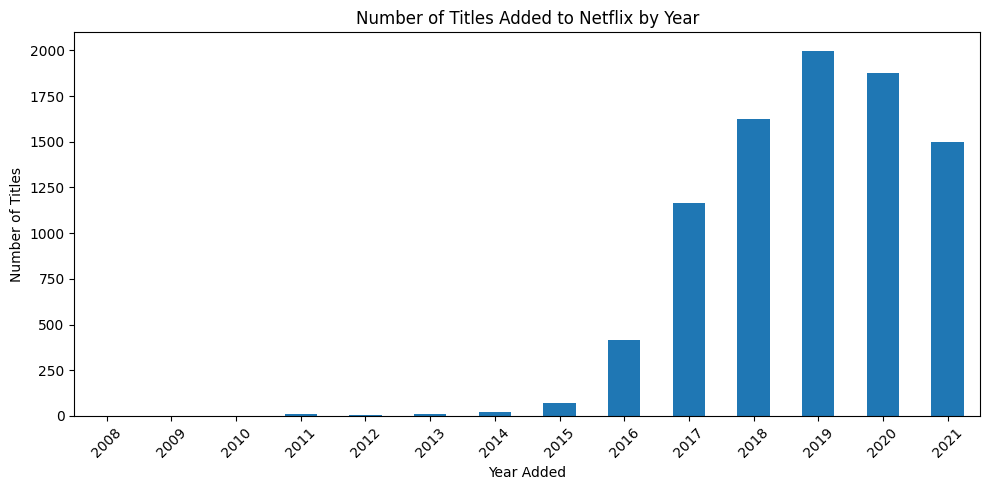

In [62]:
plt.figure(figsize=(10, 5))
titles_added_per_year.plot(kind="bar")
plt.title("Number of Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q2. what does the original release year distribution look like?

In [63]:
release_year_counts = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

release_year_counts.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

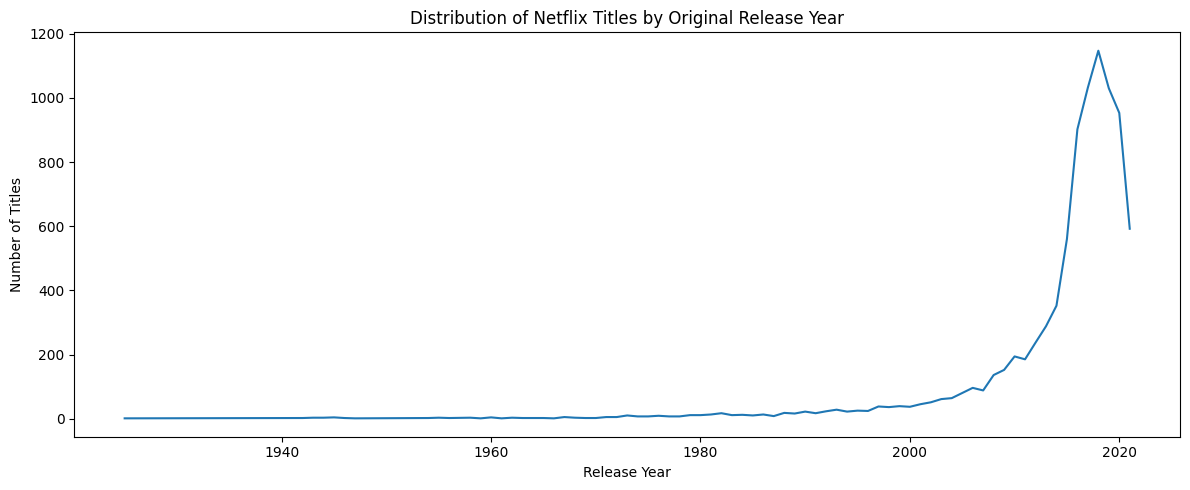

In [64]:
plt.figure(figsize=(12, 5))
release_year_counts.plot(kind="line")
plt.title("Distribution of Netflix Titles by Original Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

#### Q3. how different are release timing and addition timing?

In [65]:
df_clean["years_to_add"] = df_clean["year_added"] - df_clean["release_year"]
df_clean[["title", "release_year", "year_added", "years_to_add"]].head()

,title,release_year,year_added,years_to_add
0,Dick Johnson Is Dead,2020,2021,1
1,Blood & Water,2021,2021,0
2,Ganglands,2021,2021,0
3,Jailbirds New Orleans,2021,2021,0
4,Kota Factory,2021,2021,0


In [66]:
df_clean["years_to_add"].describe()

count      8709.0
mean     4.690894
std      8.792208
min          -3.0
25%           0.0
50%           1.0
75%           5.0
max          93.0
Name: years_to_add, dtype: Float64

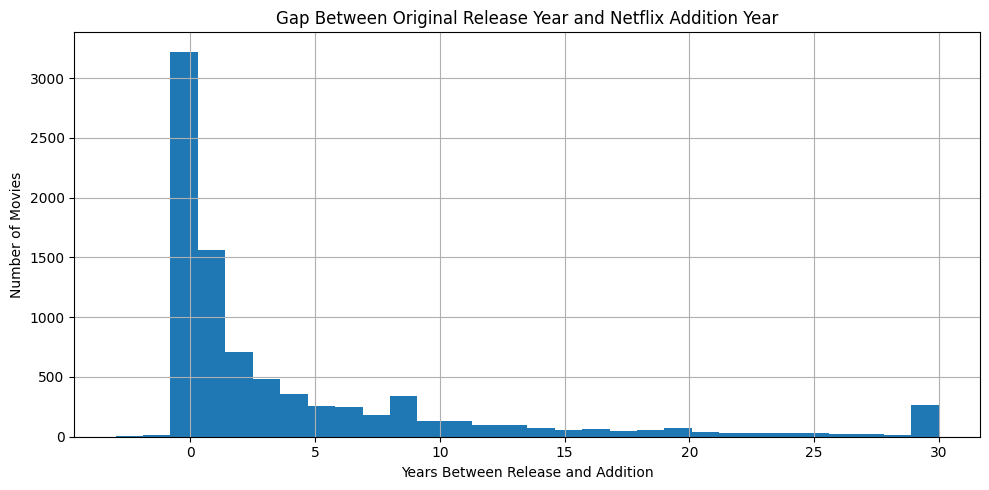

In [68]:
plt.figure(figsize=(10, 5))
df_clean["years_to_add"].dropna().clip(upper=30).hist(bins=30)
plt.title("Gap Between Original Release Year and Netflix Addition Year")
plt.xlabel("Years Between Release and Addition")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

In [69]:
df_clean[df_clean["years_to_add"] < 0][["title", "type", "release_year", "year_added", "date_added"]]

,title,type,release_year,year_added,date_added
1551,Hilda,TV Show,2021,2020,2020-12-14
1696,Polly Pocket,TV Show,2021,2020,2020-11-15
2920,Love Is Blind,TV Show,2021,2020,2020-02-13
3168,Fuller House,TV Show,2020,2019,2019-12-06
3287,Maradona in Mexico,TV Show,2020,2019,2019-11-13
3369,BoJack Horseman,TV Show,2020,2019,2019-10-25
3433,The Hook Up Plan,TV Show,2020,2019,2019-10-11
4844,Unbreakable Kimmy Schmidt,TV Show,2019,2018,2018-05-30
4845,Arrested Development,TV Show,2019,2018,2018-05-29
5394,Hans Teeuwen: Real Rancour,Movie,2018,2017,2017-07-01


In [70]:
gap_df = df_clean[df_clean["years_to_add"] >= 0].copy()
gap_df["years_to_add"].describe()

count      8695.0
mean     4.700403
std       8.79606
min           0.0
25%           0.0
50%           1.0
75%           5.0
max          93.0
Name: years_to_add, dtype: Float64

In [71]:
type_counts = df_clean["type"].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [72]:
titles_by_year_type = (
    df_clean.groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
)

titles_by_year_type

type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,4
2014,19,4
2015,56,17
2016,253,165


In [73]:
titles_by_year_type_pct = titles_by_year_type.div(titles_by_year_type.sum(axis=1), axis=0) * 100
titles_by_year_type_pct.round(2)

type,Movie,TV Show
year_added,,
2008,50.00,50.00
2009,100.00,0.00
2010,100.00,0.00
2011,100.00,0.00
2012,100.00,0.00
2013,60.00,40.00
2014,82.61,17.39
2015,76.71,23.29
2016,60.53,39.47


<Figure size 1000x500 with 0 Axes>

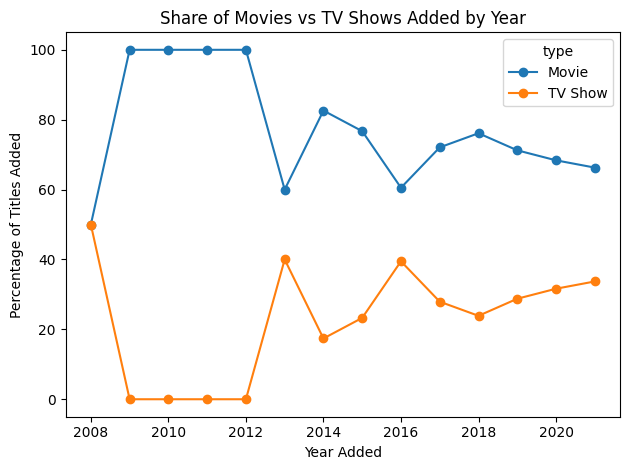

In [74]:
plt.figure(figsize=(10, 5))
titles_by_year_type_pct.plot(kind="line", marker="o")
plt.title("Share of Movies vs TV Shows Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Percentage of Titles Added")
plt.tight_layout()
plt.show()

In [75]:
top_countries = countries_exploded["country_name"].value_counts().head(15)
top_countries

country_name
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64

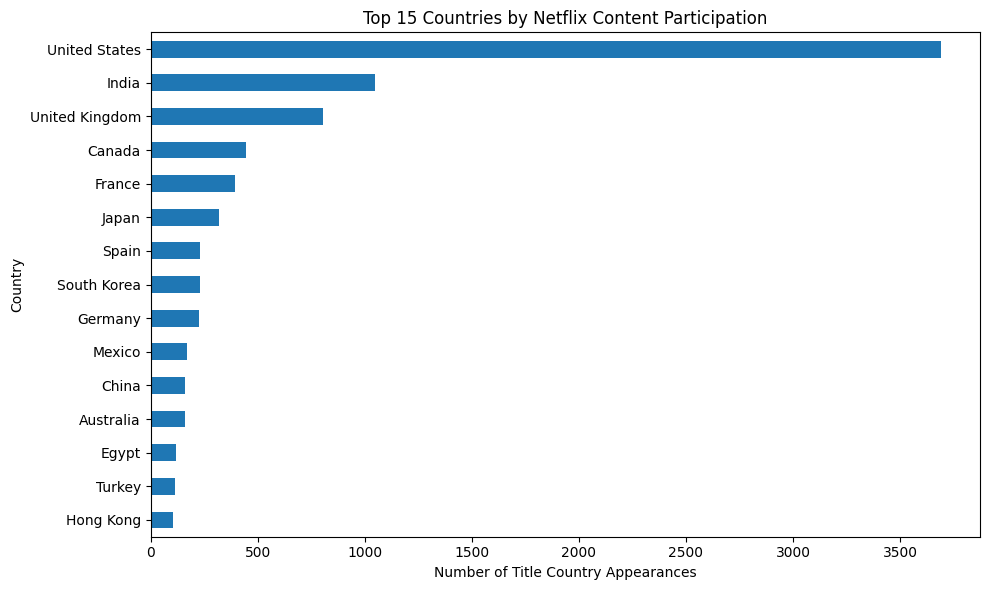

In [76]:
plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 15 Countries by Netflix Content Participation")
plt.xlabel("Number of Title Country Appearances")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [77]:
country_counts = countries_exploded["country_name"].value_counts()

top_5_share = country_counts.head(5).sum() / country_counts.sum() * 100
top_10_share = country_counts.head(10).sum() / country_counts.sum() * 100

top_5_share, top_10_share

(np.float64(63.680846814459755), np.float64(75.42440583183543))

In [78]:
top_10_country_names = country_counts.head(10).index

country_type_table = (
    countries_exploded[countries_exploded["country_name"].isin(top_10_country_names)]
    .groupby(["country_name", "type"])
    .size()
    .unstack(fill_value=0)
)

country_type_table

type,Movie,TV Show
country_name,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


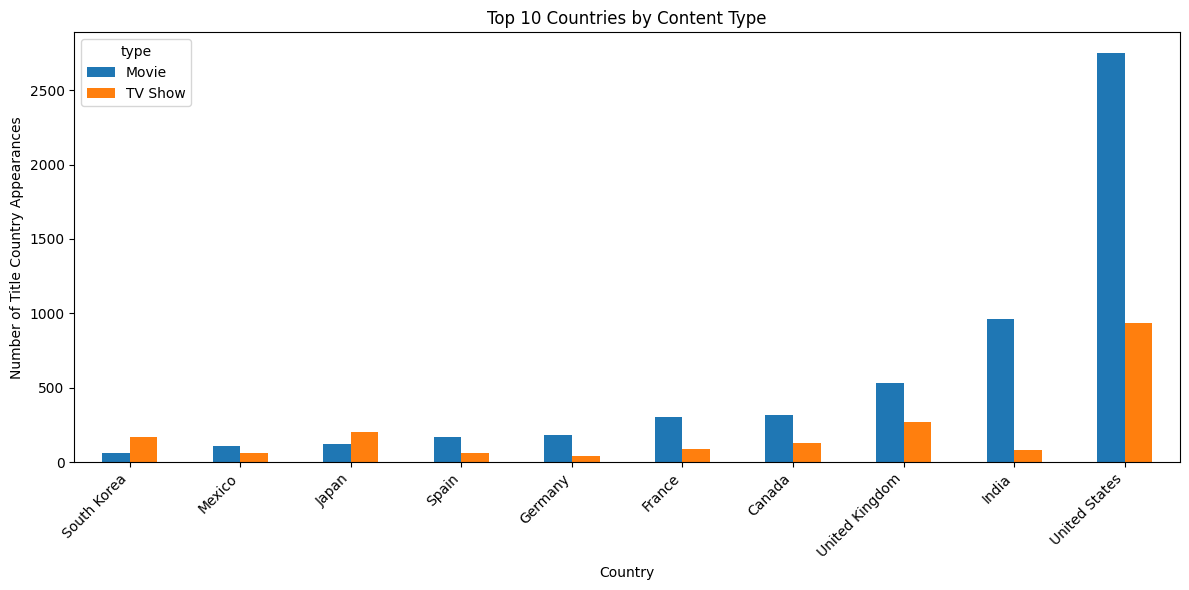

In [79]:
country_type_table.sort_values("Movie").plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Title Country Appearances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [80]:
country_type_pct = country_type_table.div(country_type_table.sum(axis=1), axis=0) * 100
country_type_pct.round(2)

type,Movie,TV Show
country_name,,
Canada,71.69,28.31
France,77.10,22.90
Germany,80.53,19.47
India,91.97,8.03
Japan,37.42,62.58
Mexico,65.68,34.32
South Korea,26.41,73.59
Spain,73.71,26.29
United Kingdom,66.17,33.83


In [81]:
top_categories = categories_exploded["category"].value_counts().head(15)
top_categories

category
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

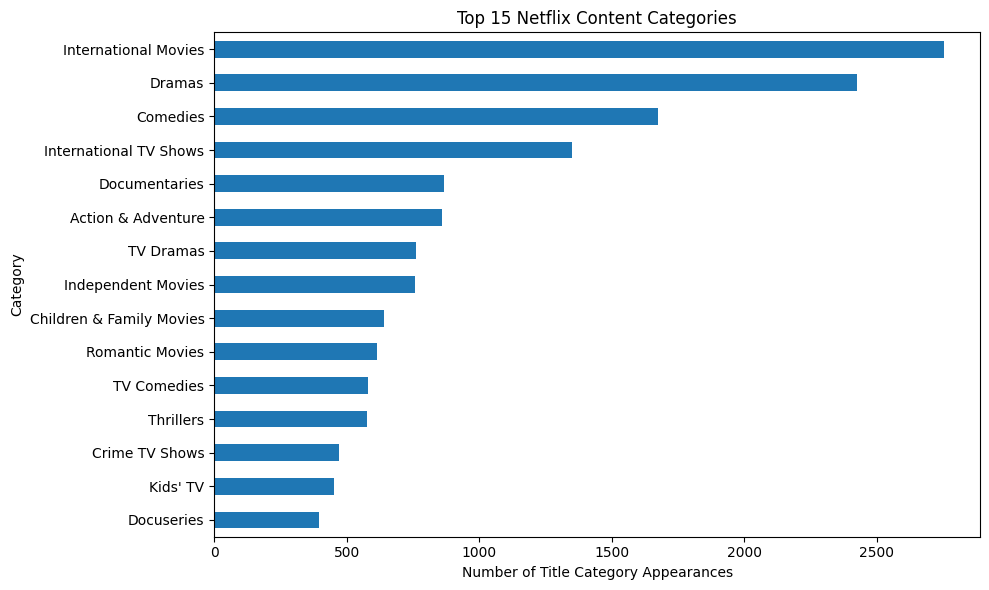

In [82]:
plt.figure(figsize=(10, 6))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 15 Netflix Content Categories")
plt.xlabel("Number of Title Category Appearances")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [83]:
category_counts = categories_exploded["category"].value_counts()

top_5_category_share = category_counts.head(5).sum() / category_counts.sum() * 100
top_10_category_share = category_counts.head(10).sum() / category_counts.sum() * 100

top_5_category_share, top_10_category_share

(np.float64(46.95440666563163), np.float64(65.76618537494177))

In [88]:
top_10_category_names = category_counts.head(20).index

category_type_table = (
    categories_exploded[categories_exploded["category"].isin(top_10_category_names)]
    .groupby(["category", "type"])
    .size()
    .unstack(fill_value=0)
)

category_type_table

type,Movie,TV Show
category,,
Action & Adventure,859,0
Children & Family Movies,641,0
Comedies,1674,0
Crime TV Shows,0,470
Documentaries,869,0
Docuseries,0,395
Dramas,2427,0
Horror Movies,357,0
Independent Movies,756,0


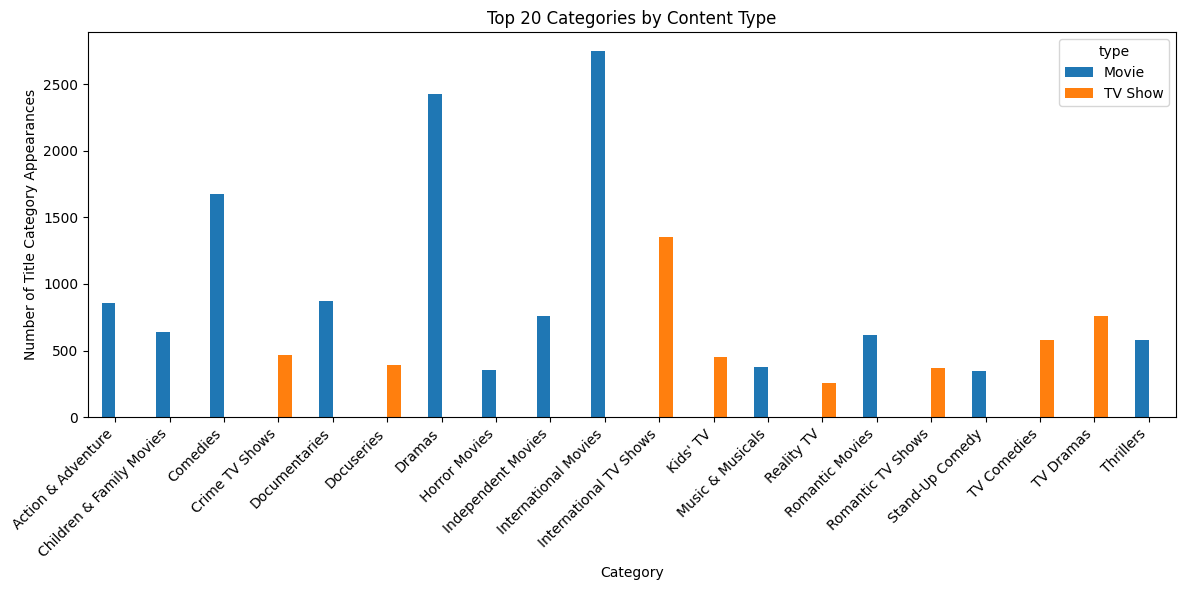

In [90]:
category_type_table.plot(kind="bar", figsize=(12, 6))
plt.title("Top 20 Categories by Content Type")
plt.xlabel("Category")
plt.ylabel("Number of Title Category Appearances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [91]:
top_directors = directors_exploded["director_name"].value_counts().head(15)
top_directors

director_name
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       11
Don Michael Paul       10
David Dhawan            9
Yılmaz Erdoğan          9
Anurag Kashyap          9
Name: count, dtype: int64

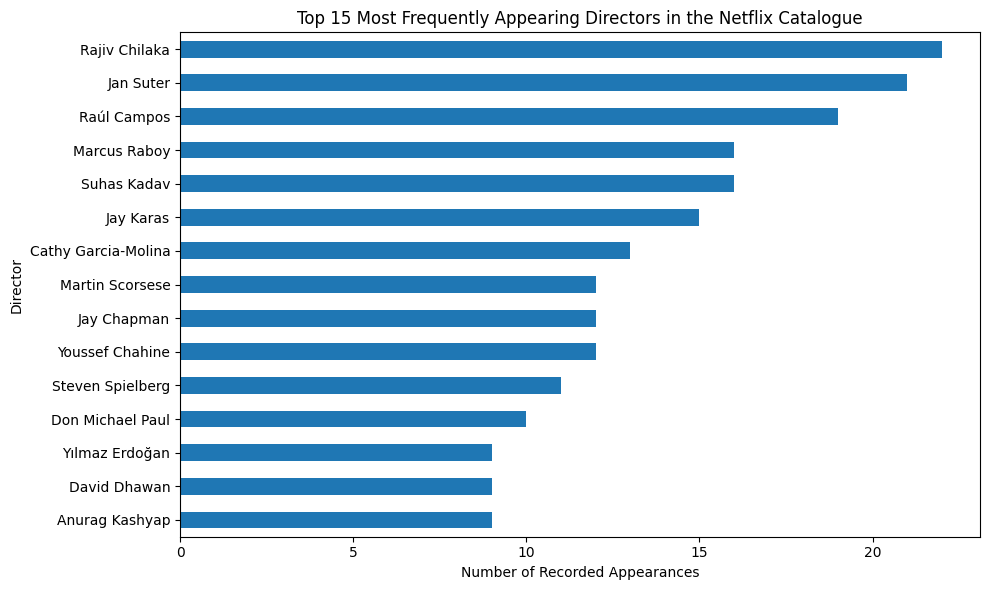

In [92]:
plt.figure(figsize=(10, 6))
top_directors.sort_values().plot(kind="barh")
plt.title("Top 15 Most Frequently Appearing Directors in the Netflix Catalogue")
plt.xlabel("Number of Recorded Appearances")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

In [93]:
top_actors = cast_exploded["actor_name"].value_counts().head(15)
top_actors

actor_name
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Paresh Rawal        28
Boman Irani         27
Rajesh Kava         26
Vincent Tong        26
Andrea Libman       25
Name: count, dtype: int64

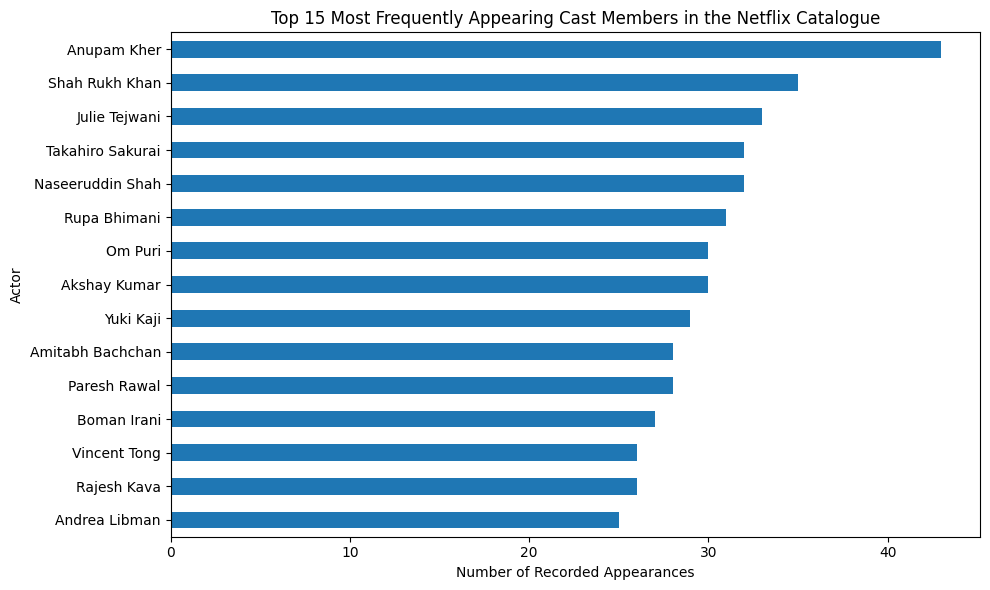

In [94]:
plt.figure(figsize=(10, 6))
top_actors.sort_values().plot(kind="barh")
plt.title("Top 15 Most Frequently Appearing Cast Members in the Netflix Catalogue")
plt.xlabel("Number of Recorded Appearances")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

In [95]:
director_counts = directors_exploded["director_name"].value_counts()

top_10_director_share = director_counts.head(10).sum() / director_counts.sum() * 100
top_20_director_share = director_counts.head(20).sum() / director_counts.sum() * 100

top_10_director_share, top_20_director_share

(np.float64(2.2642591000286614), np.float64(3.53969618801949))

In [96]:
actor_counts = cast_exploded["actor_name"].value_counts()

top_10_actor_share = actor_counts.head(10).sum() / actor_counts.sum() * 100
top_20_actor_share = actor_counts.head(20).sum() / actor_counts.sum() * 100

top_10_actor_share, top_20_actor_share

(np.float64(0.5036958487976796), np.float64(0.8951127467797773))

### Text analysis

In [111]:
stopwords_basic = {
    "the", "and", "a", "an", "of", "to", "in", "on", "for", "with", "at", "by",
    "from", "is", "it", "this", "that", "as", "his", "her", "their", "they",
    "he", "she", "them", "who", "into", "after", "when", "while", "but", "about",
    "against", "through", "out", "up", "down", "over", "under", "both", "one",
    "two", "three", "new", "life", "young", "young", "former" "are", "him", "her", "his", "their", "our", "your", "its",
    "must", "find", "finds", "found", "help", "where", "while",
    "into", "about", "around", "through", "after", "before",
    "takes", "take", "gets", "get", "goes", "go", "tries", "try",
    "sets", "set", "faces", "face", "soon", "old", "new", "back",
    "way", "ways", "comes", "come", "becomes", "become", "series",
    "story", "stories", "woman", "man", "are", "all", "has", "own", "more", "year", "years", "world"
}

In [112]:
all_description_words = " ".join(df_clean["description_clean"].dropna()).split()

In [113]:
filtered_description_words = [
    word for word in all_description_words
    if word not in stopwords_basic and len(word) > 2
]

In [114]:
filtered_description_words[:50]

['father',
 'nears',
 'end',
 'filmmaker',
 'kirsten',
 'johnson',
 'stages',
 'death',
 'inventive',
 'comical',
 'inevitable',
 'crossing',
 'paths',
 'party',
 'cape',
 'town',
 'teen',
 'prove',
 'whether',
 'private',
 'school',
 'swimming',
 'star',
 'sister',
 'was',
 'abducted',
 'birth',
 'protect',
 'family',
 'powerful',
 'drug',
 'lord',
 'skilled',
 'thief',
 'mehdi',
 'expert',
 'team',
 'robbers',
 'pulled',
 'violent',
 'deadly',
 'turf',
 'war',
 'feuds',
 'flirtations',
 'toilet',
 'talk',
 'among',
 'incarcerated',
 'women']

In [115]:
from collections import Counter

description_word_counts = Counter(filtered_description_words)
description_word_counts.most_common(20)

[('family', 635),
 ('love', 504),
 ('friends', 445),
 ('documentary', 365),
 ('school', 339),
 ('father', 317),
 ('home', 317),
 ('high', 299),
 ('lives', 277),
 ('group', 266),
 ('girl', 239),
 ('city', 226),
 ('save', 222),
 ('other', 221),
 ('town', 218),
 ('daughter', 216),
 ('teen', 213),
 ('mother', 210),
 ('son', 208),
 ('true', 208)]

In [116]:
description_words_df = pd.DataFrame(
    description_word_counts.most_common(20),
    columns=["word", "count"]
)

description_words_df

,word,count
0,family,635
1,love,504
2,friends,445
3,documentary,365
4,school,339
5,father,317
6,home,317
7,high,299
8,lives,277
9,group,266


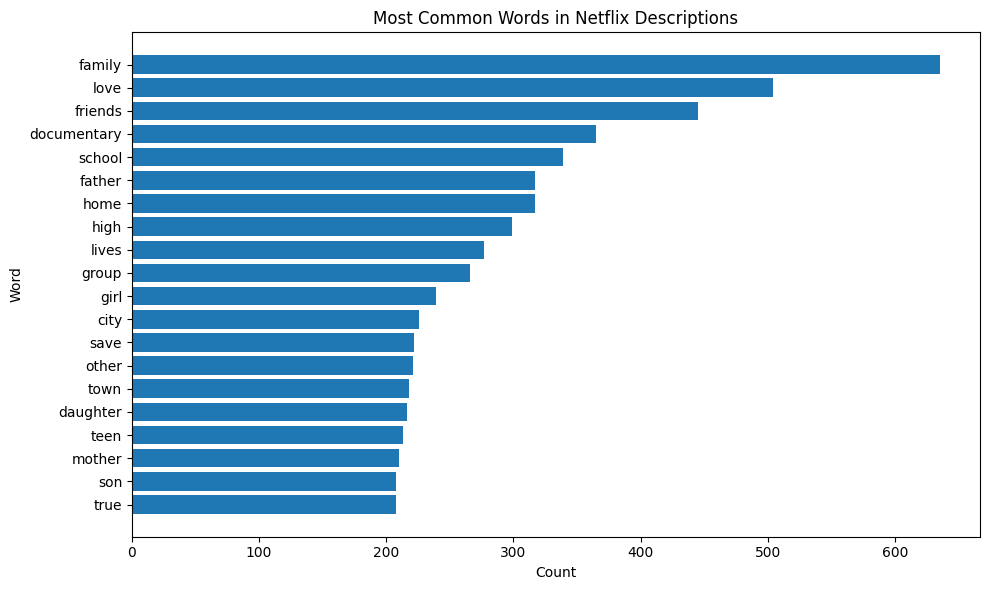

In [117]:
plt.figure(figsize=(10, 6))
plt.barh(description_words_df["word"][::-1], description_words_df["count"][::-1])
plt.title("Most Common Words in Netflix Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()